In [18]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML
from matplotlib import animation
from matplotlib.patches import Circle

import caustics
from caustics.constants import arcsec_to_rad

import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

In [19]:
# setup stuff to define a grid of points to make images

n_pix = 256
res = 0.015
fov = n_pix * res
upsample_factor = 2
z_l = torch.tensor(0.5, dtype=torch.float32)
z_s = torch.tensor(1.0, dtype=torch.float32)

In [20]:
# Define a gaussian blob for the source plane
source = caustics.Sersic(q=1.0, phi=0.0, n=0.5, Re=0.3, Ie=1.0)
# Define a cosmology for the lensing
cosmology = caustics.FlatLambdaCDM()
# Define a point mass for the lens plane
lens = caustics.Point(cosmology=cosmology, x0=0.0, y0=0.0, Rein=1.0, z_l=z_l, z_s=z_s)

# Make a bunch of theta values at which to raytrace
theta_x, theta_y = caustics.utils.meshgrid(res, n_pix)
# Evaluate the reduced deflection angles
alpha_x, alpha_y = lens.reduced_deflection_angle(theta_x, theta_y)
# Compute the lens equation at these coordinates
beta_x, beta_y = theta_x - alpha_x, theta_y - alpha_y

# Evaluate the brightness with the source moving along the x-axis
source_x = torch.linspace(-2, 2, 100)
source_y = torch.zeros(100)
unlensed_images = torch.vmap(lambda x: source.brightness(theta_x, theta_y, x))(
    torch.stack((source_x, source_y), dim=1),
)
lensed_images = torch.vmap(lambda x: source.brightness(beta_x, beta_y, x))(
    torch.stack((source_x, source_y), dim=1),
)

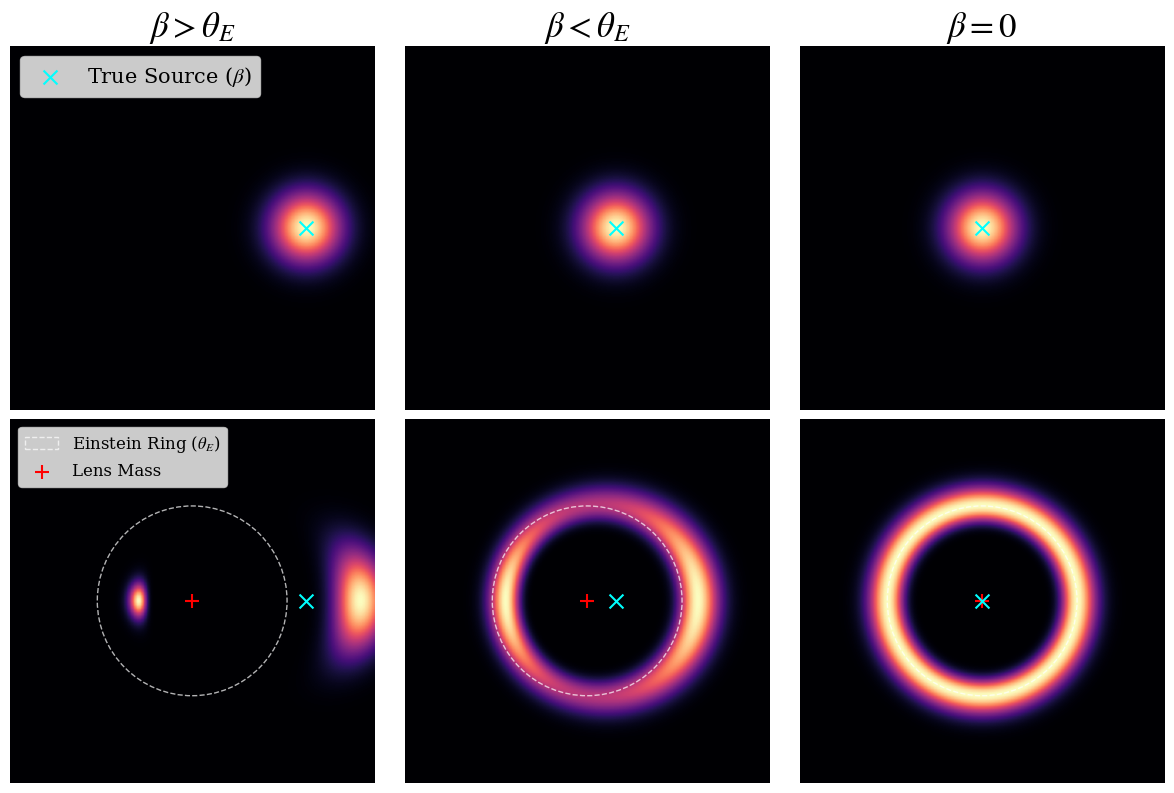

In [28]:
# Pick three specific source positions (beta_x) to illustrate the physics
source_positions = [1.2, 0.3, 0.0] 
labels = ["$\\beta > \\theta_E$", "$\\beta < \\theta_E$", "$\\beta = 0$"]

# Create a 2x3 grid of subplots for the thesis figure
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, sx in enumerate(source_positions):
    # Set the specific source position for this column
    source_coords = torch.tensor([[sx, 0.0]])
    
    # Generate the unlensed and lensed images for this specific position
    unlensed_img = source.brightness(theta_x, theta_y, source_coords).squeeze().numpy()
    lensed_img = source.brightness(beta_x, beta_y, source_coords).squeeze().numpy()
    
    # --- Top Row: Unlensed Source ---
    ax_un = axes[0, i]
    ax_un.imshow(unlensed_img, cmap="magma", origin="lower", extent=[-fov/2, fov/2, -fov/2, fov/2])
    ax_un.scatter([sx], [0], color="cyan", marker="x", s=100, label="True Source ($\\beta$)")
    ax_un.set_title(labels[i], fontsize=25)
    ax_un.axis("off")
    if i == 0:
        ax_un.legend(loc="upper left",fontsize = 15)

    # --- Bottom Row: Lensed Images ---
    ax_len = axes[1, i]
    ax_len.imshow(lensed_img, cmap="magma", origin="lower", extent=[-fov/2, fov/2, -fov/2, fov/2])
    
    # Draw the Einstein Ring
    rein = lens.Rein.value.item()
    c = Circle((0, 0), rein, fill=False, color="white", linestyle="--", alpha=0.7, label="Einstein Ring ($\\theta_E$)")
    ax_len.add_patch(c)
    
    # Mark the Lens Center and True Source Position
    ax_len.scatter([0], [0], color="red", marker="+", s=100, label="Lens Mass")
    ax_len.scatter([sx], [0], color="cyan", marker="x", s=100) # True source behind the lens
    
    ax_len.axis("off")
    if i == 0:
        ax_len.legend(loc="upper left", fontsize = 12)

plt.tight_layout()
plt.savefig(f"thesis_plots/intro_point_lensing_ex.png")
plt.show()

In [53]:
# Define a gaussian blob for the source plane
source = caustics.Sersic(q=1.0, phi=0.0, n=0.5, Re=0.3, Ie=1.0)
# Define a cosmology for the lensing
cosmology = caustics.FlatLambdaCDM()
# Define a point mass for the lens plane
lens = caustics.SIE(
    cosmology=cosmology,
    x0=0.0,
    y0=0.0,
    q=0.5,
    phi=0,
    Rein=1.0,
    z_l=z_l,
    z_s=z_s,
)
# Define a caustics simulator to handle the raytracing
sim = caustics.LensSource(lens, source, pixelscale=res, pixels_x=n_pix)

# Evaluate the brightness with the source moving along the x-axis
source_x = torch.linspace(-2, 2, 100)
sy = 0.1
source_y = torch.zeros(100) + sy
unlensed_images = torch.vmap(lambda x: sim(x, lens_source=False))(
    torch.stack((source_x, source_y), dim=1),
)
lensed_images = torch.vmap(sim)(torch.stack((source_x, source_y), dim=1))

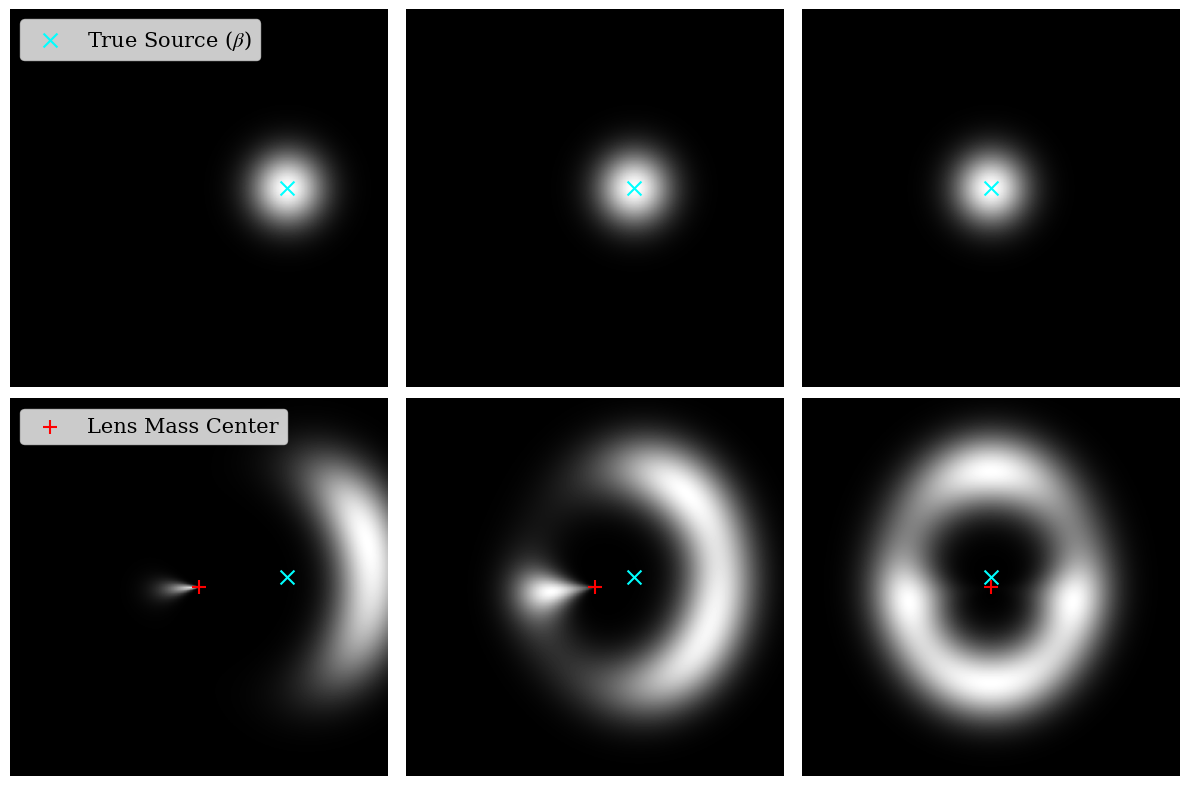

In [56]:
# Pick three specific source x-positions to illustrate the SIE physics
# Note: source_y is fixed at 0.1 to break perfect symmetry and show realistic arcs/quads
source_positions = [0.9, 0.4, 0.0] 
# labels = ["Outside Caustics (Single Image)", "Fold Crossing (Arc/Double)", "Inside Caustic (Quadruple)"]

# Create a 2x3 grid of subplots for the thesis figure
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, sx in enumerate(source_positions):
    # Coordinates tensor: [x, y]
    source_coords = torch.tensor([sx, sy], dtype=torch.float32) 
    
    # Generate images using the LensSource simulator
    unlensed_img = sim(source_coords, lens_source=False).numpy()
    lensed_img = sim(source_coords).numpy()
    
    # --- Top Row: Unlensed Source ---
    ax_un = axes[0, i]
    ax_un.imshow(unlensed_img, cmap="gist_gray", origin="lower", extent=[-fov/2, fov/2, -fov/2, fov/2])
    ax_un.scatter([sx], [sy], color="cyan", marker="x", s=100, label="True Source ($\\beta$)")
    # ax_un.set_title(labels[i], fontsize=14)
    ax_un.axis("off")
    if i == 0:
        ax_un.legend(loc="upper left", fontsize = 15)

    # --- Bottom Row: Lensed Images ---
    ax_len = axes[1, i]
    ax_len.imshow(lensed_img, cmap="gist_gray", origin="lower", extent=[-fov/2, fov/2, -fov/2, fov/2])
    
    # Mark the Lens Center and True Source Position
    ax_len.scatter([0], [0], color="red", marker="+", s=100, label="Lens Mass Center")
    ax_len.scatter([sx], [sy], color="cyan", marker="x", s=100) # True source behind the lens
    
    ax_len.axis("off")
    if i == 0:
        ax_len.legend(loc="upper left", fontsize = 15)

plt.tight_layout()
plt.savefig(f"thesis_plots/intro_sie_lensing_ex.png")
plt.show()

In [57]:
F = 100
source = caustics.Sersic(x0=0.1, y0=0.1, q=1.0, phi=0.0, n=2, Re=0.05)
T = caustics.Param("T")  # time variable
source.Ie = (
    lambda p: torch.sin(2 * 2 * np.pi * (p["T"].value % (2 * np.pi))) ** 2
)  # periodic brightness
source.Ie.link(T)
cosmology = caustics.FlatLambdaCDM()
lens = caustics.SIE(
    cosmology=cosmology,
    x0=0.0,
    y0=0.0,
    q=0.5,
    phi=0,
    Rein=1.0,
    z_l=z_l,
    z_s=z_s,
)
t = torch.linspace(0, 1, F)
theta_x, theta_y = caustics.utils.meshgrid(res, n_pix)
source_images = torch.vmap(lambda t: source.brightness(theta_x, theta_y, [t]))(t)
# Time delay fields
td_field = lens.time_delay(theta_x, theta_y) / 365
td_geometric = (
    lens.time_delay(
        theta_x,
        theta_y,
        shapiro_time_delay=False,
        geometric_time_delay=True,
    )
    / 365
)
td_shapiro = (
    lens.time_delay(
        theta_x,
        theta_y,
        shapiro_time_delay=True,
        geometric_time_delay=False,
    )
    / 365
)
# Raytrace including time delay
beta_x, beta_y = lens.raytrace(theta_x, theta_y)
lensed_images = torch.vmap(lambda t: source.brightness(beta_x, beta_y, [t + td_field]))(
    t,
)

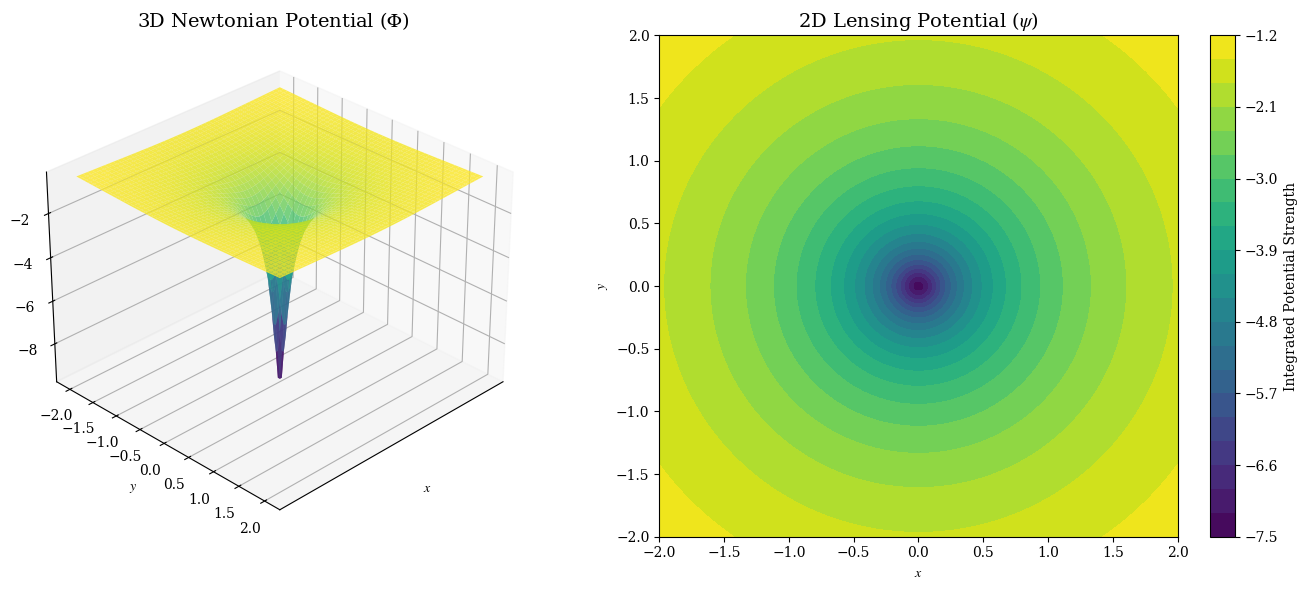

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup a 3D grid
n = 100
lim = 2.0
x = np.linspace(-lim, lim, n)
y = np.linspace(-lim, lim, n)
z = np.linspace(-lim, lim, n)
X, Y = np.meshgrid(x, y)

# 2. Define Newtonian Potential (Point Mass with softening)
def get_phi(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2 + 0.1**2) # 0.1 is 'softening' to avoid infinity
    return -1.0 / r

# Calculate a 2D slice of the 3D potential at z=0
Phi_slice = get_phi(X, Y, 0)

# 3. Calculate Lensing Potential (Numerical Integration along z-axis)
dz = z[1] - z[0]
psi_map = np.zeros((n, n))
for zi in z:
    psi_map += get_phi(X, Y, zi) * dz

# Create Figure
fig = plt.figure(figsize=(14, 6))

# --- Subplot 1: The 3D Landscape (Newtonian) ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Phi_slice, cmap='viridis', alpha=0.8)
ax1.set_title("3D Newtonian Potential ($\Phi$)", fontsize=14)
ax1.set_zlabel("Potential Energy")
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_zlabel('$z$')
ax1.set_xticks([])
ax1.view_init(elev=30, azim=45)

# --- Subplot 2: The 2D Map (Lensing) ---
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, psi_map, levels=20, cmap='viridis')
ax2.set_title("2D Lensing Potential ($\psi$)", fontsize=14)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
plt.colorbar(contour, ax=ax2, label="Integrated Potential Strength")

plt.tight_layout()
# plt.savefig("potential_comparison.png")
plt.show()

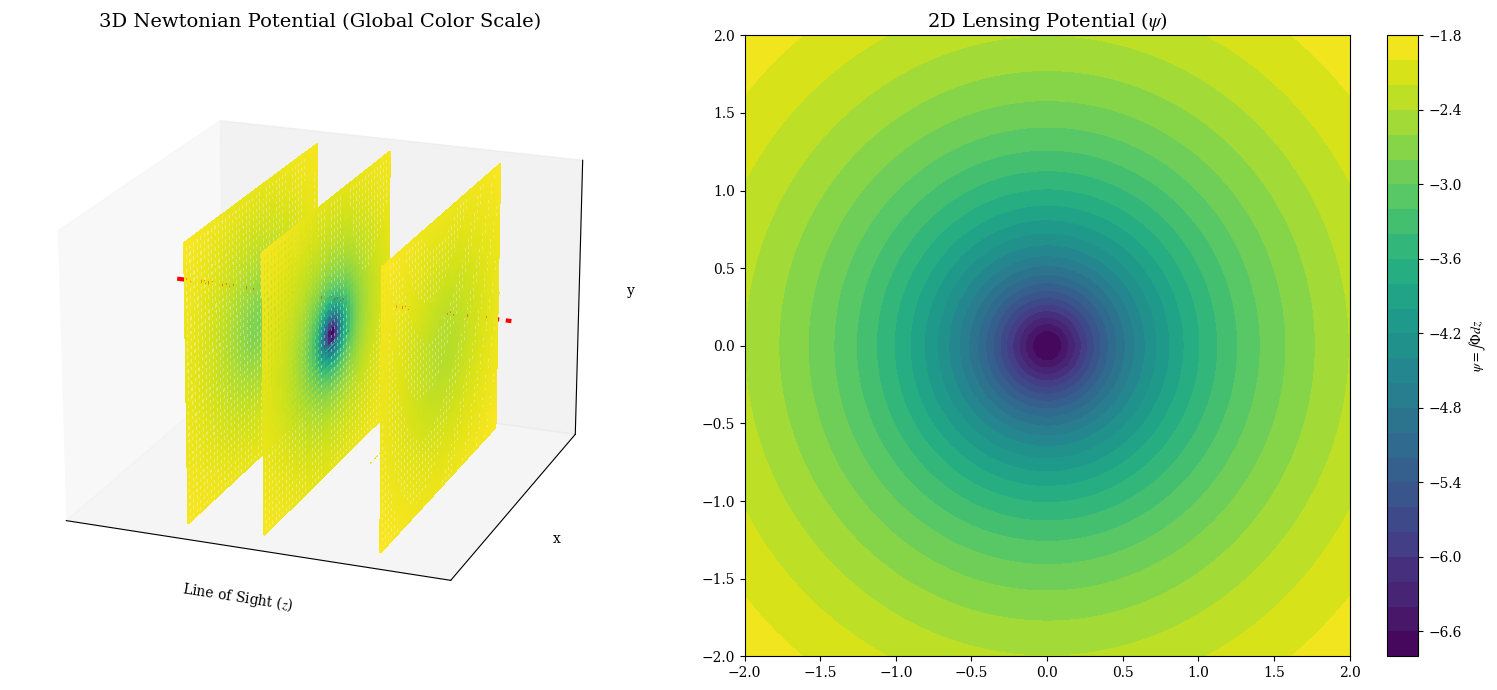

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup a 3D grid
n = 80 
lim = 2.0
coords = np.linspace(-lim, lim, n)
Y_plane, Z_plane = np.meshgrid(coords, coords)

def get_phi(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2 + 0.2**2) 
    return -1.0 / r

# --- Calculate Global Min/Max for consistent coloring ---
# We check the deepest point (x=0, y=0, z=0) and the shallowest point (edges)
phi_min = get_phi(0, 0, 0)
phi_max = get_phi(lim, lim, lim)

fig = plt.figure(figsize=(16, 7))

# --- Subplot 1: Consistent "Fog" Slices ---
ax1 = fig.add_subplot(121, projection='3d')

x_slices = [-0.8, 0.0, 1.2] 
colormaps = ['viridis', 'viridis', 'viridis']
labels = ['Source Side ($z=-1.2$)', 'Lens Center ($z=0$)', 'Observer Side ($z=1.2$)']

for i, xi in enumerate(x_slices):
    phi_slice = get_phi(xi, Y_plane, Z_plane)
    
    # Use Global Normalization: map the slice values to the 0-1 range of the WHOLE potential
    norm_phi = (phi_slice - phi_min) / (phi_max - phi_min)
    
    face_colors = plt.colormaps[colormaps[i]](norm_phi)
    
    ax1.plot_surface(np.full_like(Y_plane, xi), Y_plane, Z_plane, 
                     facecolors=face_colors, shade=False, alpha=0.6, antialiased=False)
    
    # ax1.text(xi, lim + 0.2, lim, labels[i], color='black', fontsize=9, weight='bold')

ax1.plot([-1.8, 1.8], [0.4, 0.4], [0.4, 0.4], color='red', linestyle='--', linewidth=3)
ax1.set_title("3D Newtonian Potential (Global Color Scale)", fontsize=14)
ax1.set_xlabel('Line of Sight ($z$)')
ax1.set_zlabel('y')
ax1.set_ylabel('x')
ax1.set_xlim(-2, 2)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])
ax1.view_init(elev=20, azim=-69)

# --- Subplot 2: The Integrated Lensing Potential ---
x_fine = np.linspace(-3, 3, 100)
dx = x_fine[1] - x_fine[0]
psi_map = np.zeros((n, n))
for xi in x_fine:
    psi_map += get_phi(xi, Y_plane, Z_plane) * dx

ax2 = fig.add_subplot(122)
contour = ax2.contourf(Y_plane, Z_plane, psi_map, levels=25, cmap='viridis')
ax2.set_title("2D Lensing Potential ($\psi$)", fontsize=14)
plt.colorbar(contour, ax=ax2, label=r'$\psi = \int \Phi dz$')

plt.tight_layout()
plt.show()

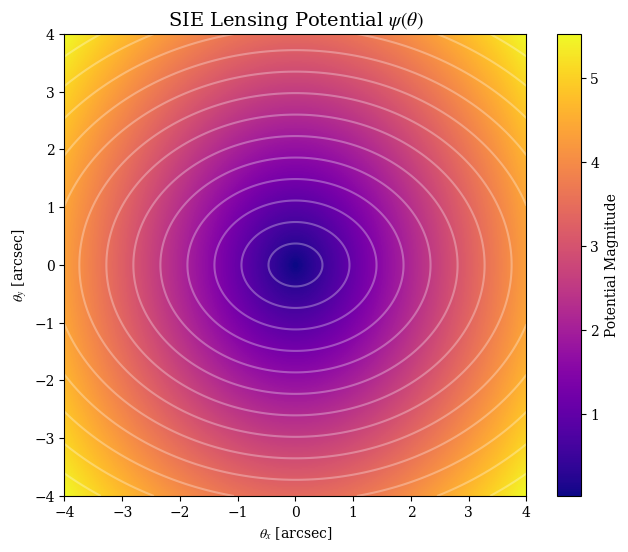

In [62]:
import matplotlib.pyplot as plt
import torch

# 1. Create a coordinate grid (theta_x, theta_y) for the lens plane
# Use the resolution and pixel count from your simulator
res = 0.04  # arcsec/pixel
n_pix = 200
fov = res * n_pix
thx, thy = torch.meshgrid(
    torch.linspace(-fov/2, fov/2, n_pix),
    torch.linspace(-fov/2, fov/2, n_pix),
    indexing='ij'
)

# 2. Evaluate the potential of your SIE lens
# Note: lens.potential() returns the 2D map psi
psi_sie = lens.potential(thx, thy)

# 3. Plot the Heat Map
plt.figure(figsize=(8, 6))
im = plt.imshow(
    psi_sie.numpy(), 
    extent=[-fov/2, fov/2, -fov/2, fov/2], 
    origin='lower', 
    cmap='plasma'
)

# Add contours to highlight the ellipticity (q=0.5)
plt.contour(thx.numpy(), thy.numpy(), psi_sie.numpy(), levels=15, colors='white', alpha=0.3)

plt.title("SIE Lensing Potential $\psi(\\theta)$", fontsize=14)
plt.xlabel(r"$\theta_x$ [arcsec]")
plt.ylabel(r"$\theta_y$ [arcsec]")
plt.colorbar(im, label=r"Potential Magnitude")
plt.show()

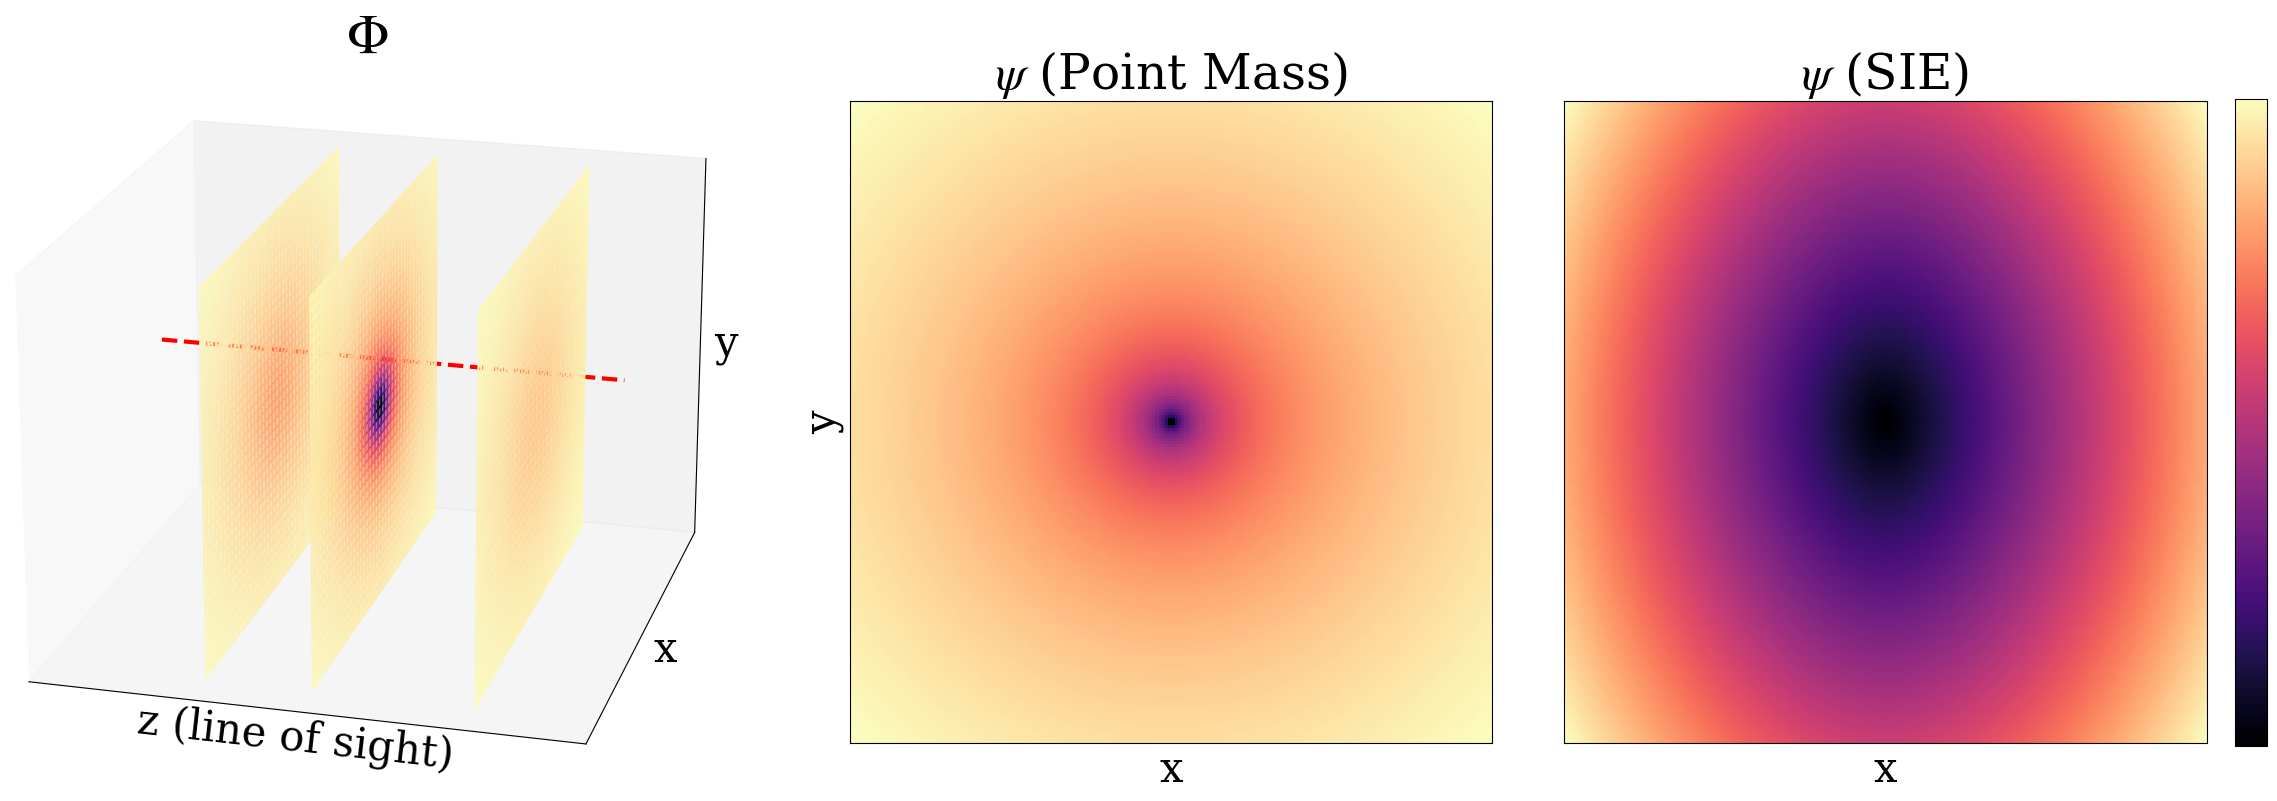

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import caustics # Assuming caustics is imported

# --- Settings ---
res, n_pix = 0.04, 200
fov = res * n_pix
thx, thy = torch.meshgrid(
    torch.linspace(-fov/2, fov/2, n_pix),
    torch.linspace(-fov/2, fov/2, n_pix),
    indexing='ij'
)

# Dummy values for z_l, z_s, cosmology - ensure these are defined in your notebook
# z_l, z_s = 0.5, 1.0
# cosmology = caustics.FlatLambdaCDM()

# --- Create Figure ---
fig = plt.figure(figsize=(24, 8))
gs = gridspec.GridSpec(1, 10, figure=fig)

# 1. Subplot: 3D Newtonian Potential Slices
# (Using n=80 here for performance, it doesn't affect the 2D plots)
n_3d = 80
coords_3d = np.linspace(-2.0, 2.0, n_3d)
Y_3d, Z_3d = np.meshgrid(coords_3d, coords_3d)

def get_phi(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2 + 0.2**2) 
    return -1.0 / r

ax1 = fig.add_subplot(gs[0, 0:4], projection='3d')
ax1.set_box_aspect(None, zoom=1.2)
plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.1)

phi_min, phi_max = get_phi(0, 0, 0), get_phi(2.0, 2.0, 2.0)
x_slices = [-0.8, 0.0, 1.2] 

for xi in x_slices:
    phi_slice = get_phi(xi, Y_3d, Z_3d)
    norm_phi = (phi_slice - phi_min) / (phi_max - phi_min)
    ax1.plot_surface(np.full_like(Y_3d, xi), Y_3d, Z_3d, 
                     facecolors=plt.cm.magma(norm_phi), shade=False, alpha=0.6)

ax1.plot([-1.8, 1.8], [0.4, 0.4], [0.4, 0.4], color='red', linestyle='--', linewidth=3)
ax1.set_title("$\Phi$", fontsize=40, pad=-10) # Pad brings title closer
ax1.set_xlabel('z (line of sight)', size = 30, labelpad=-10); ax1.set_ylabel('x', size = 30, labelpad=-10); ax1.set_zlabel('y', size = 30, labelpad=-10)
ax1.view_init(elev=20, azim=-75)
ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

# 2. Subplot: The Integrated Lensing Potential (Point Source)
# We use caustics.Point to represent the 'Integrated' version of the 3D slices
lens_ps = caustics.Point(cosmology=cosmology, x0=0.0, y0=0.0, Rein=1.0, z_l=z_l, z_s=z_s)
psi_ps = lens_ps.potential(thx, thy)

ax2 = fig.add_subplot(gs[0, 4:7])

im2 = ax2.imshow(
    psi_ps.numpy(), 
    extent=[-fov/2, fov/2, -fov/2, fov/2], 
    origin='lower', 
    cmap='magma'
)
# Add contours for the point source
# ax2.contour(thx.numpy(), thy.numpy(), psi_ps.numpy(), levels=15, colors='white', alpha=0.3)
ax2.set_title(r"$\psi$ (Point Mass)", fontsize=35)
ax2.set_xlabel('x', size=30); ax2.set_ylabel('y', size=30)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_aspect('equal') 

cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.ax.set_visible(False) # Hides the bar but keeps the "spacing" footprint

# 3. Subplot: The SIE Lensing Potential (Simulation)
lens_sie = caustics.SIE(cosmology=cosmology, x0=0.0, y0=0.0, q=0.3, phi=0, Rein=1.0, z_l=z_l, z_s=z_s)
psi_sie = lens_sie.potential(thx, thy)

ax3 = fig.add_subplot(gs[0, 7:10])

im3 = ax3.imshow(
    psi_sie.numpy(), 
    extent=[-fov/2, fov/2, -fov/2, fov/2], 
    origin='lower', 
    cmap='magma'
)
# Note: contours now show the ellipticity (q=0.5)
# ax3.contour(thx.numpy(), thy.numpy(), psi_sie.numpy(), levels=15, colors='white', alpha=0.3)
ax3.set_title(r"$\psi$ (SIE)", fontsize=35)
ax3.set_xlabel('x', size=30) #; ax3.set_ylabel('y', size=20)
ax3.set_xticks([]); ax3.set_yticks([])
ax3.set_aspect('equal') 
cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_ticks([])

plt.tight_layout()
fig.subplots_adjust(wspace=0.05)
plt.savefig(f"thesis_plots/lensing_potentials.png")
plt.show()

In [143]:
F = 100
hirez = 2
source = caustics.Sersic(q=1.0, phi=0.0, n=0.5, Re=0.3, Ie=1.0)
cosmology = caustics.FlatLambdaCDM()
lens = caustics.ExternalShear(cosmology=cosmology, x0=0.0, y0=0.0, z_l=z_l, z_s=z_s)
sim = caustics.LensSource(lens, source, pixelscale=res / hirez, pixels_x=hirez * n_pix)


# Create the constant zero tensors for x0 and y0
zeros = torch.zeros_like(gamma_1)
# Stack all 4 required parameters: (gamma_1, gamma_2, x0, y0)
# For the first animation (varying gamma_1)
params1 = torch.stack((gamma_1, zeros, zeros, zeros), dim=1)
# For the second animation (varying gamma_2)
params2 = torch.stack((zeros, gamma_2, zeros, zeros), dim=1)
# Now vmap will work because the input size (4) matches the registered params
lensed_images1 = torch.vmap(sim)(params1)
lensed_images2 = torch.vmap(sim)(params2)


# Create animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Display the first frame of the image in the first subplot
im1 = ax1.imshow(lensed_images1[0].numpy(), cmap="grey")
ax1.set_title("Shear Field $\\gamma_1$")
ax1.axis("off")
im2 = ax2.imshow(
    lensed_images2[0].numpy(),
    cmap="grey",
)
ax2.set_title("Shear Field $\\gamma_2$")
ax2.axis("off")


def update(frame):
    """Update function for the animation."""
    # Update the image in the first subplot
    im1.set_array(lensed_images1[frame].numpy())
    ax1.set_title(f"Shear Field $\\gamma_1 = {gamma_1[frame].item():.2f}$")
    im2.set_array(lensed_images2[frame].numpy())
    ax2.set_title(f"Shear Field $\\gamma_2 = {gamma_2[frame].item():.2f}$")

    return im1, im2


ani = animation.FuncAnimation(fig, update, frames=F, interval=60, repeat=True)

plt.close()
HTML(ani.to_jshtml())

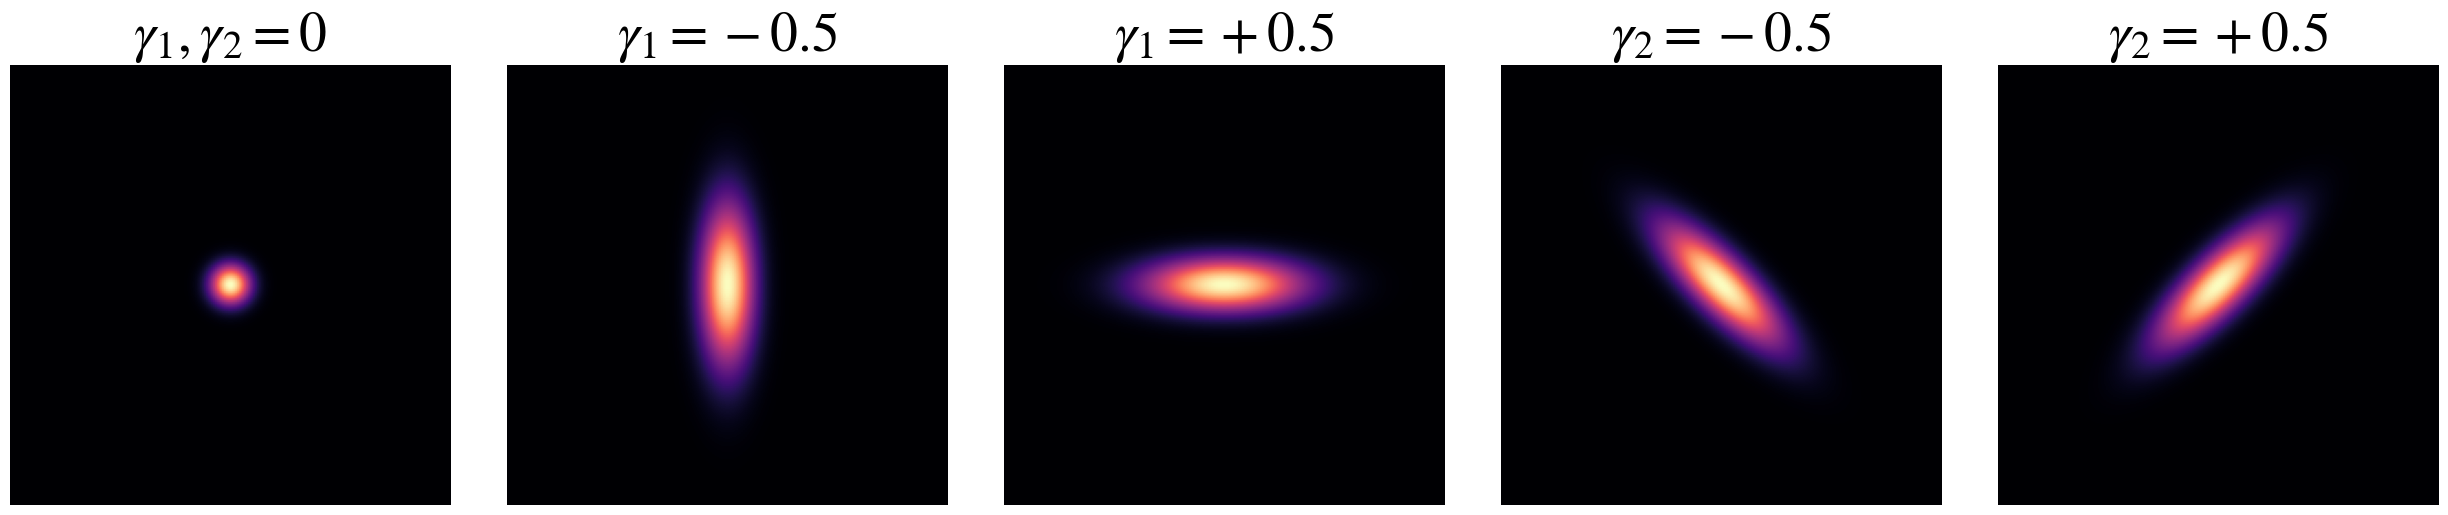

In [154]:
import torch
import matplotlib.pyplot as plt
import caustics

# --- Setup ---
hirez = 2
n_pix_hires = hirez * n_pix
pixelscale_hires = res / hirez

# 1. Define the Source and Lens
source = caustics.Sersic(q=1.0, phi=0.0, n=0.5, Re=0.3, Ie=1.0)
cosmology = caustics.FlatLambdaCDM()
lens = caustics.ExternalShear(cosmology=cosmology, x0=0.0, y0=0.0, z_l=z_l, z_s=z_s)
sim = caustics.LensSource(lens, source, pixelscale=pixelscale_hires, pixels_x=n_pix_hires)

# 2. Generate the 5 Images
# We evaluate the simulator at specific (gamma1, gamma2, x0, y0) points

# A. Original (No Shear)
thx_hires, thy_hires = torch.meshgrid(
    torch.linspace(-fov/2, fov/2, n_pix_hires),
    torch.linspace(-fov/2, fov/2, n_pix_hires),
    indexing='ij'
)

# You must pass the registered parameters (x0, y0) as a tensor
# Sersic expects a tensor of length 2 for (x0, y0)
sersic_params = torch.tensor([0.0, 0.0]) 
img_none = source.brightness(thx_hires, thy_hires, sersic_params)
# B. Gamma 1 variations
img_g1_neg = sim(torch.tensor([-0.5, 0.0, 0.0, 0.0]))
img_g1_pos = sim(torch.tensor([0.5, 0.0, 0.0, 0.0]))

# C. Gamma 2 variations
img_g2_neg = sim(torch.tensor([0.0, -0.5, 0.0, 0.0]))
img_g2_pos = sim(torch.tensor([0.0, 0.5, 0.0, 0.0]))

# --- Plotting ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
titles = [
    "$\gamma_1, \gamma_2 = 0$", 
    "$\gamma_1 = -0.5$", "$\gamma_1 = +0.5$", 
     "$\gamma_2 = -0.5$", "$\gamma_2 = +0.5$"
]
images = [img_none, img_g1_neg, img_g1_pos, img_g2_neg, img_g2_pos]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img.numpy(), cmap="magma", origin="lower")
    ax.set_title(title, fontsize=40)
    ax.axis("off")

plt.tight_layout()
plt.savefig("thesis_plots/shear.png", bbox_inches='tight', dpi=300)
plt.show()